# Rygte spredning


## Rygte-modellen

In [2]:
import random
import math
%matplotlib inline
%matplotlib ipympl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

class Person:
    def __init__(self, x, y, tilstand):
        self.x = x
        self.y = y
        self.tilstand = tilstand  # her tildeles personobjektet dets formelle tilstand

    def flyt(self):  #metode flytter personen
        vinkel = random.uniform(0, 2*math.pi)
        self.x += math.cos(vinkel) * 0.03
        self.y += math.sin(vinkel) * 0.03
        self.x = min(max(self.x, 0), 1)  # sikrer, at personen bliver inden for området
        self.y = min(max(self.y, 0), 1)  # som ovenfor

class Simulering:
    def __init__(self, antal, rygteRate, rygteradius):
        self.personer = []
        self.rygteRate = rygteRate
        self.rygteradius = rygteradius
        for _ in range(antal):
            x, y = random.random(), random.random()  # tildeler tilfældige koordinater
            if len(self.personer) == 0:  #vi starter med 1 person som kender rygtet
                tilstand = 'Hørt rygtet' 
            else:
                tilstand = 'Ikke hørt rygtet'
            self.personer.append(Person(x, y, tilstand))  # der konstrueres personobjekter som tilføjes listen personer

    def step(self):
        for p in self.personer:  # vi gennemløber listen personer for alle personobjekter p
            p.flyt()

        for p in self.personer:  # vi gennemløber listen personer for alle personobjekter p
            if p.tilstand == 'Ikke hørt rygtet':
                for q in self.personer:
                    if q.tilstand == 'Hørt rygtet':
                        distance = math.dist((p.x, p.y), (q.x, q.y))  # bestemmer afstanden mellem de to personer
                        if distance < self.rygteradius and random.random() < self.rygteRate:
                            p.tilstand = 'Hørt rygtet' # personen tildeles tilstanden hørt rygtet
                            break

class Visualisering:
    def __init__(self, sim):
        self.sim = sim
        self.fig, self.ax = plt.subplots(figsize=(6,6))
        self.historik = []

    def opdater(self, frame):
        self.sim.step()
        self.ax.clear()
        
        xS = []
        yS = []
        xI = []
        yI = []
   
        for p in self.sim.personer:
            if p.tilstand == 'Ikke hørt rygtet':
                xS.append(p.x)
                yS.append(p.y)
            if p.tilstand == 'Hørt rygtet':
                xI.append(p.x)
                yI.append(p.y)

        self.historik.append([len(xS), len(xI)])

        self.ax.scatter(xS, yS, color='blue', label='Ikke hørt rygtet', s=10)  #plotter personer på canvas udfra aktuelle parametre
        self.ax.scatter(xI, yI, color='red', label='Hørt rygtet', s=10)  # same

        self.ax.set_xlim(0, 1)
        self.ax.set_ylim(0, 1)
        self.ax.set_title('Har du hørt model')
        self.ax.legend(loc='upper right')

    def animer(self):
        self.anim = FuncAnimation(self.fig, self.opdater, frames=300, interval=50)
        display(HTML(self.anim.to_jshtml()))

sim = Simulering(antal=400, rygteRate=0.25, rygteradius=0.016) #rygteradius er sat ned da man jo skal snakke sammen for at sprede rygter
vis = Visualisering(sim)
vis.animer()

RuntimeError: 'ipympl is not a recognised GUI loop or backend name

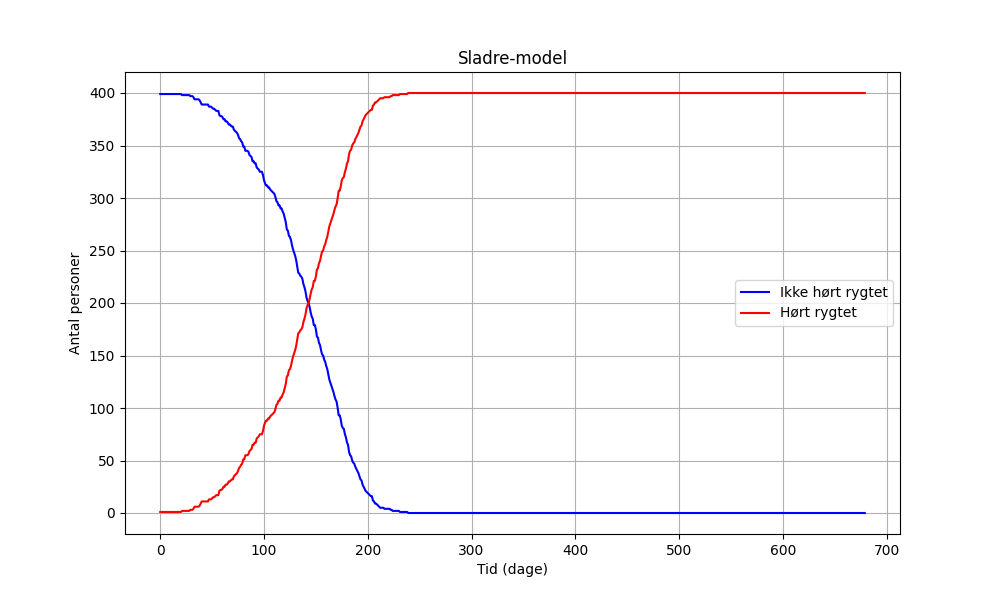

In [ ]:
S = []
I = []
for h in vis.historik:
    S.append(h[0])
    I.append(h[1])
plt.figure(figsize=(10, 6))
plt.plot(S, label='Ikke hørt rygtet', color='blue')
plt.plot(I, label='Hørt rygtet', color='red')
plt.xlabel('Tid (dage)')
plt.ylabel('Antal personer')
plt.title('Sladre-model')
plt.legend()
plt.grid(True)
plt.show()

Scratch model hvor der ved sladder både er mulighed for at en person spreder rygtet eller forbliver tavs

https://scratch.mit.edu/projects/1290261593 